# Graph Feasibility Analysis from SHAP Cosine Signals

This notebook loads server/client SHAP artifacts for one FL run, reproduces the hybrid cosine detection signals used in runtime detection, and evaluates whether graph spectral clustering can separate malicious and benign clients effectively.

In [83]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    jaccard_score,
    silhouette_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

RUN_PATH = Path(
    "/home/b-fatma/master/federated/experiments/shap_outputs/FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10"
)
SERVER_REF_PATH = RUN_PATH / "server-model" / "reference_shap.npz"

ALPHA = 0.7
MAD_MULTIPLIER = 3.0
MIN_CLIENTS = 3
RANDOM_STATE = 42

print(f"Run path: {RUN_PATH}")
print(f"Server reference: {SERVER_REF_PATH}")
print(f"alpha={ALPHA}, mad_multiplier={MAD_MULTIPLIER}, min_clients={MIN_CLIENTS}")

Run path: /home/b-fatma/master/federated/experiments/shap_outputs/FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10
Server reference: /home/b-fatma/master/federated/experiments/shap_outputs/FEDAVG_mlp_adult-income-census_ep3_lr0.001_bs8_iid_attack_mpaf_lambda10/server-model/reference_shap.npz
alpha=0.7, mad_multiplier=3.0, min_clients=3


In [84]:
def load_json(path: Path) -> dict:
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path: Path) -> np.ndarray | None:
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)], dtype=float)
        if arr.ndim == 1:
            return arr.astype(float)
        return np.mean(arr, axis=0).astype(float)
    except Exception:
        return None


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    va = np.asarray(a, dtype=float).reshape(-1)
    vb = np.asarray(b, dtype=float).reshape(-1)
    na = float(np.linalg.norm(va))
    nb = float(np.linalg.norm(vb))
    if na < 1e-12 or nb < 1e-12:
        return 0.0
    return float(np.dot(va, vb) / (na * nb))


def zscore_map(score_map: dict[str, float]) -> dict[str, float]:
    if not score_map:
        return {}
    vals = np.asarray(list(score_map.values()), dtype=float)
    mu = float(np.mean(vals))
    sigma = float(np.std(vals))
    if sigma < 1e-12:
        return {k: 0.0 for k in score_map}
    return {k: float((v - mu) / sigma) for k, v in score_map.items()}


def mad_lower_threshold(values, multiplier: float = 3.0) -> float:
    vals = np.asarray(list(values), dtype=float)
    if vals.size == 0:
        return 0.0
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    mad_scaled = max(1e-12, 1.4826 * mad)
    return med - multiplier * mad_scaled


def pairwise_average_cosine(client_vectors: dict[str, np.ndarray]) -> dict[str, float]:
    ids = list(client_vectors.keys())
    n = len(ids)
    if n <= 1:
        return {cid: 0.0 for cid in ids}

    sums = {cid: 0.0 for cid in ids}
    for i, cid_i in enumerate(ids):
        vi = client_vectors[cid_i]
        for j in range(i + 1, n):
            cid_j = ids[j]
            sim = cosine_sim(vi, client_vectors[cid_j])
            sums[cid_i] += sim
            sums[cid_j] += sim
    return {cid: float(sums[cid] / (n - 1)) for cid in ids}


def pairwise_matrix(
    client_vectors: dict[str, np.ndarray], order: list[str]
) -> np.ndarray:
    n = len(order)
    mat = np.zeros((n, n), dtype=float)
    for i, ci in enumerate(order):
        mat[i, i] = 1.0
        for j in range(i + 1, n):
            s = cosine_sim(client_vectors[ci], client_vectors[order[j]])
            mat[i, j] = s
            mat[j, i] = s
    return mat

In [85]:
if not SERVER_REF_PATH.exists():
    raise FileNotFoundError(f"Server reference SHAP not found: {SERVER_REF_PATH}")

server_shap_ref = load_npz_vector(SERVER_REF_PATH)
if server_shap_ref is None:
    raise RuntimeError(f"Could not load server reference vector: {SERVER_REF_PATH}")

round_vectors: dict[int, dict[str, np.ndarray]] = defaultdict(dict)
round_labels: dict[int, dict[str, int]] = defaultdict(dict)

round_dirs = sorted(
    [d for d in RUN_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")],
    key=lambda p: int(p.name.split("_")[1]),
)

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    client_dirs = sorted([d for d in rdir.iterdir() if d.is_dir()])
    for cdir in client_dirs:
        meta = load_json(cdir / "metadata.json")
        vec = load_npz_vector(cdir / "shap_values.npz")
        if vec is None:
            continue
        client_id = cdir.name
        malicious = meta.get("malicious", meta.get("is_malicious", False))
        if malicious is None:
            malicious = False
        round_vectors[rnum][client_id] = vec
        round_labels[rnum][client_id] = int(bool(malicious))

print(f"Loaded rounds: {len(round_vectors)}")
print(f"Server reference shape: {server_shap_ref.shape}")
if round_vectors:
    first_round = min(round_vectors)
    print(f"Round {first_round} clients loaded: {len(round_vectors[first_round])}")

Loaded rounds: 20
Server reference shape: (30,)
Round 1 clients loaded: 30


In [86]:
records = []
round_thresholds = {}
round_flagged_sets = {}

for rnum in sorted(round_vectors):
    client_vectors = round_vectors[rnum]
    labels_map = round_labels[rnum]
    n = len(client_vectors)
    if n < MIN_CLIENTS:
        continue

    server_scores = {
        cid: cosine_sim(vec, server_shap_ref) for cid, vec in client_vectors.items()
    }
    pair_scores = pairwise_average_cosine(client_vectors)
    z_server = zscore_map(server_scores)
    z_pair = zscore_map(pair_scores)

    fused = {
        cid: float(ALPHA * z_server[cid] + (1.0 - ALPHA) * z_pair[cid])
        for cid in client_vectors
    }
    threshold = mad_lower_threshold(fused.values(), multiplier=MAD_MULTIPLIER)
    flagged = {cid for cid, score in fused.items() if score < threshold}

    round_thresholds[rnum] = threshold
    round_flagged_sets[rnum] = flagged

    for cid in sorted(client_vectors):
        records.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": labels_map.get(cid, 0),
                "server_cosine": server_scores[cid],
                "pairwise_cosine": pair_scores[cid],
                "z_server": z_server[cid],
                "z_pairwise": z_pair[cid],
                "fused_score": fused[cid],
                "threshold": threshold,
                "flagged": int(cid in flagged),
            }
        )

df_det = pd.DataFrame(records)
print(f"Detection table rows: {len(df_det)}")
print(
    f"Rounds in detection table: {df_det['round'].nunique() if not df_det.empty else 0}"
)
df_det.head()

Detection table rows: 600
Rounds in detection table: 20


,round,client,is_malicious,server_cosine,pairwise_cosine,z_server,z_pairwise,fused_score,threshold,flagged
0,1,client_1,1,-0.783563,-0.355532,-2.468552,-1.852158,-2.283634,0.188324,1
1,1,client_10,1,-0.264434,-0.237025,-1.416708,-1.503665,-1.442795,0.188324,1
2,1,client_11,0,0.715167,0.503172,0.568131,0.673014,0.599596,0.188324,0
3,1,client_12,0,0.787513,0.505641,0.714716,0.680274,0.704383,0.188324,0
4,1,client_13,1,-0.199991,-0.359713,-1.286136,-1.864453,-1.459631,0.188324,1


In [87]:
spec_records = []
round_pairwise_mats = {}
round_orders = {}

for rnum in sorted(round_vectors):
    client_vectors = round_vectors[rnum]
    order = sorted(client_vectors.keys())
    n = len(order)
    if n < MIN_CLIENTS:
        continue

    mat_cos = pairwise_matrix(client_vectors, order)
    # Affinity for spectral clustering: clip negatives to zero.
    mat_aff = np.clip(mat_cos, 0.0, 1.0)
    np.fill_diagonal(mat_aff, 1.0)

    # Normalized Laplacian eigenvalues (symmetric).
    degree = np.sum(mat_aff, axis=1)
    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degree, 1e-12)))
    lap = np.eye(n) - d_inv_sqrt @ mat_aff @ d_inv_sqrt
    eigvals = np.linalg.eigvalsh(lap)
    eigvals = np.sort(np.real(eigvals))
    eigengap_k2 = float(eigvals[2] - eigvals[1]) if n >= 3 else np.nan

    y_true = np.array([round_labels[rnum].get(cid, 0) for cid in order], dtype=int)

    try:
        clusterer = SpectralClustering(
            n_clusters=2,
            affinity="precomputed",
            random_state=RANDOM_STATE,
            assign_labels="kmeans",
        )
        y_cluster = clusterer.fit_predict(mat_aff).astype(int)
    except Exception:
        y_cluster = np.zeros(n, dtype=int)

    # Align cluster labels to malicious=1 orientation using whichever mapping gives better F1.
    y_pred_a = y_cluster
    y_pred_b = 1 - y_cluster
    f1_a = f1_score(y_true, y_pred_a, zero_division=0)
    f1_b = f1_score(y_true, y_pred_b, zero_division=0)
    y_pred = y_pred_a if f1_a >= f1_b else y_pred_b

    ari = adjusted_rand_score(y_true, y_cluster)
    nmi = normalized_mutual_info_score(y_true, y_cluster)
    silhouette = np.nan
    try:
        if len(np.unique(y_cluster)) > 1:
            silhouette = float(silhouette_score(mat_aff, y_cluster, metric="euclidean"))
    except Exception:
        silhouette = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    det_map = (
        df_det[df_det["round"] == rnum].set_index("client")
        if not df_det.empty
        else pd.DataFrame()
    )
    if not det_map.empty:
        y_det = np.array(
            [
                int(det_map.loc[cid, "flagged"]) if cid in det_map.index else 0
                for cid in order
            ],
            dtype=int,
        )
        det_jaccard = jaccard_score(y_pred, y_det, zero_division=0)
    else:
        det_jaccard = np.nan

    round_pairwise_mats[rnum] = mat_cos
    round_orders[rnum] = order

    spec_records.append(
        {
            "round": rnum,
            "n_clients": n,
            "eig0": float(eigvals[0]) if n >= 1 else np.nan,
            "eig1": float(eigvals[1]) if n >= 2 else np.nan,
            "eig2": float(eigvals[2]) if n >= 3 else np.nan,
            "eigengap_k2": eigengap_k2,
            "spectral_ari": float(ari),
            "spectral_nmi": float(nmi),
            "spectral_silhouette": silhouette,
            "spectral_precision": float(precision),
            "spectral_recall": float(recall),
            "spectral_f1": float(f1),
            "spectral_tp": int(tp),
            "spectral_fp": int(fp),
            "spectral_fn": int(fn),
            "spectral_tn": int(tn),
            "spectral_vs_detector_jaccard": float(det_jaccard)
            if not np.isnan(det_jaccard)
            else np.nan,
        }
    )

df_spec = pd.DataFrame(spec_records).sort_values("round")
print(f"Spectral rows: {len(df_spec)}")
df_spec.head()

Spectral rows: 20


,round,n_clients,eig0,eig1,eig2,eigengap_k2,spectral_ari,spectral_nmi,spectral_silhouette,spectral_precision,spectral_recall,spectral_f1,spectral_tp,spectral_fp,spectral_fn,spectral_tn,spectral_vs_detector_jaccard
0,1,30,3.482457e-16,0.054332,0.375634,0.321302,0.188914,0.170425,0.595994,0.833333,0.416667,0.555556,5,1,7,17,0.600000
1,2,30,-1.410871e-16,0.181622,0.276306,0.094684,0.128478,0.119654,0.536110,0.800000,0.333333,0.470588,4,1,8,17,0.625000
2,3,30,-5.344176e-16,0.166557,0.318166,0.151609,0.187882,0.259117,0.461243,1.000000,0.333333,0.500000,4,0,8,18,0.444444
3,4,30,-3.902732e-16,0.194171,0.400508,0.206337,0.424256,0.446599,0.498037,1.000000,0.583333,0.736842,7,0,5,18,0.583333
4,5,30,8.740059e-16,0.192461,0.376786,0.184325,0.336384,0.380332,0.474829,1.000000,0.500000,0.666667,6,0,6,18,0.500000


In [88]:
det_round = (
    df_det.groupby("round")
    .apply(
        lambda x: pd.Series(
            {
                "det_tp": int(((x["is_malicious"] == 1) & (x["flagged"] == 1)).sum()),
                "det_fp": int(((x["is_malicious"] == 0) & (x["flagged"] == 1)).sum()),
                "det_fn": int(((x["is_malicious"] == 1) & (x["flagged"] == 0)).sum()),
                "det_tn": int(((x["is_malicious"] == 0) & (x["flagged"] == 0)).sum()),
            }
        )
    )
    .reset_index()
    if not df_det.empty
    else pd.DataFrame(columns=["round", "det_tp", "det_fp", "det_fn", "det_tn"])
)

if not det_round.empty:
    det_round["det_precision"] = det_round["det_tp"] / np.maximum(
        det_round["det_tp"] + det_round["det_fp"], 1
    )
    det_round["det_recall"] = det_round["det_tp"] / np.maximum(
        det_round["det_tp"] + det_round["det_fn"], 1
    )
    det_round["det_f1"] = (
        2
        * det_round["det_precision"]
        * det_round["det_recall"]
        / np.maximum(det_round["det_precision"] + det_round["det_recall"], 1e-12)
    )

df_summary = (
    pd.merge(df_spec, det_round, on="round", how="left")
    if not df_spec.empty
    else pd.DataFrame()
)

print("Overall detector confusion:")
if not df_det.empty:
    y_true_det = df_det["is_malicious"].astype(int).values
    y_pred_det = df_det["flagged"].astype(int).values
    tn, fp, fn, tp = confusion_matrix(y_true_det, y_pred_det, labels=[0, 1]).ravel()
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
    print(f"Precision={precision_score(y_true_det, y_pred_det, zero_division=0):.4f}")
    print(f"Recall={recall_score(y_true_det, y_pred_det, zero_division=0):.4f}")
    print(f"F1={f1_score(y_true_det, y_pred_det, zero_division=0):.4f}")

print("\nSpectral summary means:")
if not df_spec.empty:
    print(
        df_spec[
            [
                "spectral_ari",
                "spectral_nmi",
                "spectral_f1",
                "spectral_vs_detector_jaccard",
            ]
        ].mean(numeric_only=True)
    )

df_summary.head()

Overall detector confusion:
TP=180 FP=22 FN=69 TN=329
Precision=0.8911
Recall=0.7229
F1=0.7982

Spectral summary means:
spectral_ari                    0.339030
spectral_nmi                    0.339601
spectral_f1                     0.665602
spectral_vs_detector_jaccard    0.455139
dtype: float64


,round,n_clients,eig0,eig1,eig2,eigengap_k2,spectral_ari,spectral_nmi,spectral_silhouette,spectral_precision,...,spectral_fn,spectral_tn,spectral_vs_detector_jaccard,det_tp,det_fp,det_fn,det_tn,det_precision,det_recall,det_f1
0,1,30,3.482457e-16,0.054332,0.375634,0.321302,0.188914,0.170425,0.595994,0.833333,...,7,17,0.600000,9,1,3,17,0.900,0.750000,0.818182
1,2,30,-1.410871e-16,0.181622,0.276306,0.094684,0.128478,0.119654,0.536110,0.800000,...,8,17,0.625000,7,1,5,17,0.875,0.583333,0.700000
2,3,30,-5.344176e-16,0.166557,0.318166,0.151609,0.187882,0.259117,0.461243,1.000000,...,8,18,0.444444,9,0,3,18,1.000,0.750000,0.857143
3,4,30,-3.902732e-16,0.194171,0.400508,0.206337,0.424256,0.446599,0.498037,1.000000,...,5,18,0.583333,12,0,0,18,1.000,1.000000,1.000000
4,5,30,8.740059e-16,0.192461,0.376786,0.184325,0.336384,0.380332,0.474829,1.000000,...,6,18,0.500000,12,0,0,18,1.000,1.000000,1.000000


In [89]:
print(df_summary)

    round  n_clients          eig0      eig1      eig2  eigengap_k2  \
0       1         30  3.482457e-16  0.054332  0.375634     0.321302   
1       2         30 -1.410871e-16  0.181622  0.276306     0.094684   
2       3         30 -5.344176e-16  0.166557  0.318166     0.151609   
3       4         30 -3.902732e-16  0.194171  0.400508     0.206337   
4       5         30  8.740059e-16  0.192461  0.376786     0.184325   
5       6         30 -2.671127e-16  0.159680  0.334242     0.174562   
6       7         30 -5.253530e-16  0.147475  0.318942     0.171467   
7       8         30 -3.106917e-17  0.148534  0.287811     0.139277   
8       9         30 -3.044548e-16  0.149231  0.313657     0.164427   
9      10         30  6.438583e-17  0.142511  0.335562     0.193050   
10     11         30 -1.040905e-15  0.138757  0.325661     0.186904   
11     12         30 -4.523291e-16  0.094034  0.318013     0.223979   
12     13         30  1.117812e-16  0.112643  0.311778     0.199135   
13    

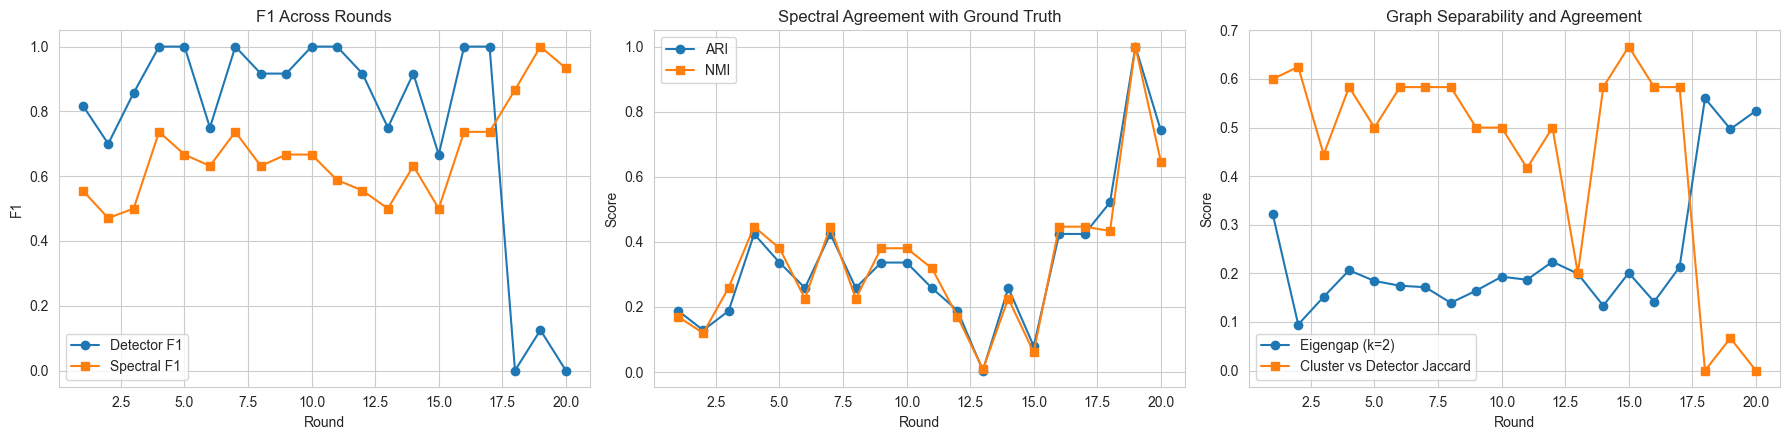

In [90]:
if not df_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(
        df_summary["round"], df_summary["det_f1"], marker="o", label="Detector F1"
    )
    axes[0].plot(
        df_summary["round"], df_summary["spectral_f1"], marker="s", label="Spectral F1"
    )
    axes[0].set_title("F1 Across Rounds")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("F1")
    axes[0].legend()

    axes[1].plot(
        df_summary["round"], df_summary["spectral_ari"], marker="o", label="ARI"
    )
    axes[1].plot(
        df_summary["round"], df_summary["spectral_nmi"], marker="s", label="NMI"
    )
    axes[1].set_title("Spectral Agreement with Ground Truth")
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    axes[2].plot(
        df_summary["round"],
        df_summary["eigengap_k2"],
        marker="o",
        label="Eigengap (k=2)",
    )
    axes[2].plot(
        df_summary["round"],
        df_summary["spectral_vs_detector_jaccard"],
        marker="s",
        label="Cluster vs Detector Jaccard",
    )
    axes[2].set_title("Graph Separability and Agreement")
    axes[2].set_xlabel("Round")
    axes[2].set_ylabel("Score")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No summary data to plot.")

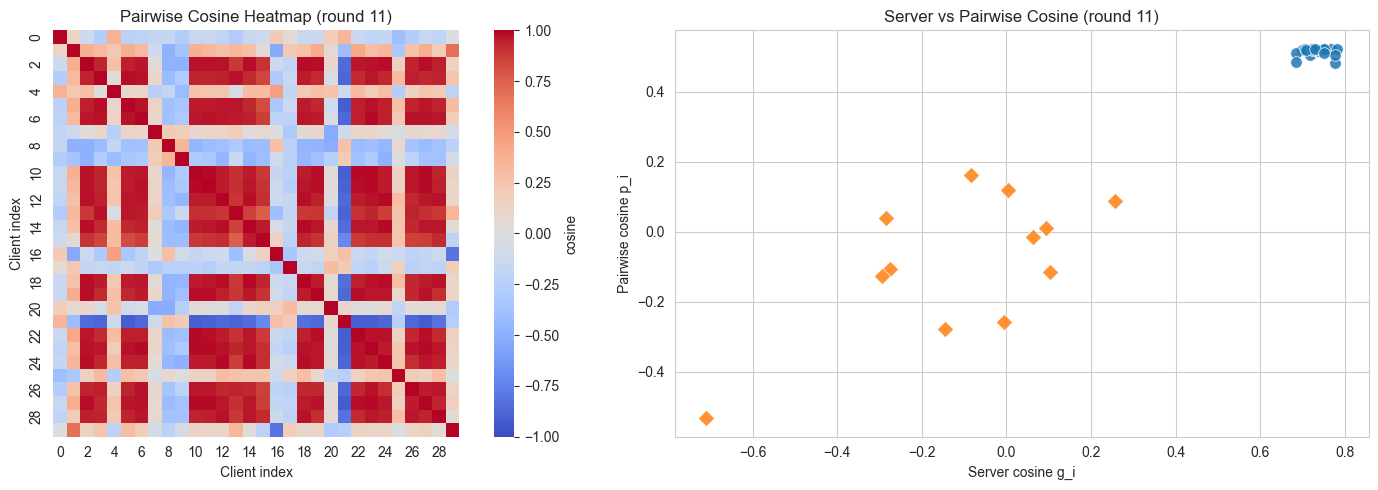

In [91]:
selected_round = None
if round_pairwise_mats:
    selected_round = sorted(round_pairwise_mats.keys())[len(round_pairwise_mats) // 2]

if selected_round is not None:
    mat = round_pairwise_mats[selected_round]
    order = round_orders[selected_round]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.heatmap(
        mat,
        ax=axes[0],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"label": "cosine"},
    )
    axes[0].set_title(f"Pairwise Cosine Heatmap (round {selected_round})")
    axes[0].set_xlabel("Client index")
    axes[0].set_ylabel("Client index")

    det_r = df_det[df_det["round"] == selected_round].copy()
    det_r = det_r.sort_values("client")
    x = np.arange(len(det_r))
    colors = ["tab:orange" if y == 1 else "tab:blue" for y in det_r["is_malicious"]]
    markers = ["D" if y == 1 else "o" for y in det_r["flagged"]]
    for i, row in enumerate(det_r.itertuples()):
        axes[1].scatter(
            row.server_cosine,
            row.pairwise_cosine,
            color=colors[i],
            marker=markers[i],
            s=70,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.6,
        )
    axes[1].set_title(f"Server vs Pairwise Cosine (round {selected_round})")
    axes[1].set_xlabel("Server cosine g_i")
    axes[1].set_ylabel("Pairwise cosine p_i")

    plt.tight_layout()
    plt.show()
else:
    print("No pairwise matrices available for plotting.")

## Interpretation Guide

Use these checks to decide whether spectral clustering is promising:

- Strong signal: consistently positive ARI/NMI and stable spectral F1 over rounds.
- Graph separability: larger eigengap around k=2 tends to indicate cleaner two-group structure.
- Complementarity: moderate overlap (Jaccard) with detector flags can indicate spectral adds new signal rather than duplicating thresholding.
- If ARI/NMI are weak while detector F1 is stronger, hybrid thresholding is likely the safer primary detector for this run.

## GNN-Based Clustering

This section learns node embeddings from each round graph using a small unsupervised GCN-style autoencoder, then clusters embeddings into 2 groups and compares with detector/spectral results.

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GNN_HIDDEN = 16
GNN_EMB = 8
GNN_EPOCHS = 300
GNN_LR = 1e-2
GNN_WD = 1e-4
FEATURE_RECON_W = 0.2
K_CLUSTERS = 2

print("GNN device:", DEVICE)

GNN device: cpu


In [93]:
def normalize_adjacency(a: np.ndarray) -> np.ndarray:
    d = np.sum(a, axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    d_inv_sqrt = np.diag(d_inv_sqrt)
    return d_inv_sqrt @ a @ d_inv_sqrt


def build_round_features(rnum: int, order: list[str]) -> np.ndarray:
    det_r = df_det[df_det["round"] == rnum].set_index("client")
    cols = ["server_cosine", "pairwise_cosine", "z_server", "z_pairwise", "fused_score"]
    x = np.array(
        [det_r.loc[cid, cols].values.astype(float) for cid in order], dtype=float
    )

    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (x - mu) / sd


class TinyGCNAE(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, emb_dim: int):
        super().__init__()
        self.w1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, emb_dim, bias=False)
        self.dec_x = nn.Linear(emb_dim, in_dim)

    def encode(self, x: torch.Tensor, a_hat: torch.Tensor) -> torch.Tensor:
        h = torch.relu(a_hat @ self.w1(x))
        z = a_hat @ self.w2(h)
        return z

    def forward(self, x: torch.Tensor, a_hat: torch.Tensor):
        z = self.encode(x, a_hat)
        a_rec = torch.sigmoid(z @ z.T)
        x_rec = self.dec_x(z)
        return z, a_rec, x_rec

In [94]:
gnn_rows = []

for rnum in sorted(round_pairwise_mats.keys()):
    order = round_orders[rnum]
    n = len(order)
    if n < 3:
        continue

    a = np.clip(round_pairwise_mats[rnum], 0.0, 1.0)
    np.fill_diagonal(a, 1.0)
    a_hat = normalize_adjacency(a)

    x = build_round_features(rnum, order)
    y_true = np.array([round_labels[rnum].get(cid, 0) for cid in order], dtype=int)

    x_t = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    a_t = torch.tensor(a, dtype=torch.float32, device=DEVICE)
    a_hat_t = torch.tensor(a_hat, dtype=torch.float32, device=DEVICE)

    model = TinyGCNAE(in_dim=x.shape[1], hidden_dim=GNN_HIDDEN, emb_dim=GNN_EMB).to(
        DEVICE
    )
    opt = torch.optim.Adam(model.parameters(), lr=GNN_LR, weight_decay=GNN_WD)

    for _ in range(GNN_EPOCHS):
        model.train()
        z, a_rec, x_rec = model(x_t, a_hat_t)
        loss_a = F.mse_loss(a_rec, a_t)
        loss_x = F.mse_loss(x_rec, x_t)
        loss = loss_a + FEATURE_RECON_W * loss_x
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        z = model.encode(x_t, a_hat_t).cpu().numpy()

    km = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
    y_cluster = km.fit_predict(z)

    gnn_ari = adjusted_rand_score(y_true, y_cluster)
    gnn_nmi = normalized_mutual_info_score(y_true, y_cluster)

    y_pred_a = y_cluster
    y_pred_b = 1 - y_cluster
    f1_a = f1_score(y_true, y_pred_a, zero_division=0)
    f1_b = f1_score(y_true, y_pred_b, zero_division=0)
    y_pred = y_pred_a if f1_a >= f1_b else y_pred_b

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    gnn_precision = precision_score(y_true, y_pred, zero_division=0)
    gnn_recall = recall_score(y_true, y_pred, zero_division=0)
    gnn_f1 = f1_score(y_true, y_pred, zero_division=0)

    gnn_rows.append(
        {
            "round": rnum,
            "gnn_ari": float(gnn_ari),
            "gnn_nmi": float(gnn_nmi),
            "gnn_precision": float(gnn_precision),
            "gnn_recall": float(gnn_recall),
            "gnn_f1": float(gnn_f1),
            "gnn_tp": int(tp),
            "gnn_fp": int(fp),
            "gnn_fn": int(fn),
            "gnn_tn": int(tn),
        }
    )

df_gnn = pd.DataFrame(gnn_rows).sort_values("round")
print("GNN rows:", len(df_gnn))
df_gnn.head()

GNN rows: 20


,round,gnn_ari,gnn_nmi,gnn_precision,gnn_recall,gnn_f1,gnn_tp,gnn_fp,gnn_fn,gnn_tn
0,1,0.128478,0.119654,0.800000,0.333333,0.470588,4,1,8,17
1,2,0.258442,0.225734,0.857143,0.500000,0.631579,6,1,6,17
2,3,0.127257,0.200680,0.333333,0.750000,0.461538,9,18,3,0
3,4,0.521209,0.519279,1.000000,0.666667,0.800000,8,0,4,18
4,5,0.627249,0.601196,1.000000,0.750000,0.857143,9,0,3,18


In [95]:
if "df_summary" in globals() and not df_summary.empty:
    df_summary = df_summary.drop(
        columns=[c for c in df_summary.columns if c.startswith("gnn_")], errors="ignore"
    )
    df_summary = df_summary.merge(df_gnn, on="round", how="left")
else:
    df_summary = df_gnn.copy()

print(
    df_summary[["round", "det_f1", "spectral_f1", "gnn_f1", "spectral_ari", "gnn_ari"]]
)

    round    det_f1  spectral_f1    gnn_f1  spectral_ari   gnn_ari
0       1  0.818182     0.555556  0.470588      0.188914  0.128478
1       2  0.700000     0.470588  0.631579      0.128478  0.258442
2       3  0.857143     0.500000  0.461538      0.187882  0.127257
3       4  1.000000     0.736842  0.800000      0.424256  0.521209
4       5  1.000000     0.666667  0.857143      0.336384  0.627249
5       6  0.750000     0.631579  0.782609      0.258442  0.425132
6       7  1.000000     0.736842  0.909091      0.424256  0.742386
7       8  0.916667     0.631579  0.761905      0.258442  0.424768
8       9  0.916667     0.666667  0.588235      0.336384  0.257593
9      10  1.000000     0.666667  0.857143      0.336384  0.627249
10     11  1.000000     0.588235  0.956522      0.257593  0.866631
11     12  0.916667     0.555556  0.818182      0.188914  0.521574
12     13  0.750000     0.500000  0.636364      0.004577  0.190355
13     14  0.916667     0.631579  0.869565      0.258442  0.62